In [1]:
from classy import Class

import os
import copy
import yaml
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

from matplotlib import rc
from scipy.interpolate import interp1d

rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)
#matplotlib.rc('font', **font)
matplotlib.rcParams['legend.fontsize']='medium'
plt.rcParams["figure.figsize"] = [8.0,6.0]

# warmup

run a fiducial cosmology

In [2]:
params_EDE = {
    # output options
    #"root": "output/best_fit_paper_Smithetal_",
    #"write background": "yes",
    #"write parameters": "yeap",
    # general computations
    # "compute_sigma8": "yes",

    # LCDM parameters
    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    # neutrinos
    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.71611,

    # EDE parameters
    "scf_potential": "axion",
    "n_axion": 2.6,
    "f_axion": 0.1,
    "m_axion": 1e4,
    "scf_parameters": '2.72,0',

    # extra EDE parameters
    "scf_evolve_as_fluid": "no",
    "scf_evolve_like_axionCAMB": "no",
    "do_shooting": "no",
    "do_shooting_scf": "no",
    "attractor_ic_scf": "no",

    # verbosity
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    "perturbations_verbose": 1,
    "transfer_verbose": 1,
    "primordial_verbose": 1,
    #"spectra_verbose": 1,
    # "nonlinear_verbose": 1,
    "lensing_verbose": 1,
    "output_verbose": 1,
}


In [3]:
params_mEDE = {
    # output options
#    "root": "output/best_fit_paper_Smithetal_",
    # "write background": "yes",
    # "write parameters": "yeap",

    # general computations
    #"compute_sigma8": "yes",

    # LCDM parameters
    "omega_b": 0.02251,
    "omega_cdm": 0.1320,
    "H0": 72.81,
    "tau_reio": 0.068,
    "A_s": 2.191e-9,
    "n_s": 0.9860,

    # neutrinos
    "N_ur": 2.0328,
    "N_ncdm": 1,
    "deg_ncdm": 1,
    "m_ncdm": 0.06,
    "T_ncdm": 0.71611,

    # modified scalar field (mscf) parameters
    "N_mscf": 2,
    "n_axion_mscf": '2.6, 2.6',
    "f_axion_mscf": '0.1, 0.1',
    "m_mscf": '1e4,1e4',
    "phi_ini_mscf": '0.272, 0.272',
    "phi_prime_ini_mscf": '0.0,0.0',

    # verbosity
    "input_verbose": 1,
    "background_verbose": 1,
    "thermodynamics_verbose": 1,
    # "perturbations_verbose": 1,
    # "transfer_verbose": 1,
    # "primordial_verbose": 1,
    #"spectra_verbose": 1,
    #"nonlinear_verbose": 1,
    #"lensing_verbose": 1,
    # "output_verbose": 1,
}

In [4]:
EDE1 = Class()
EDEm = Class()
EDE1.set(params_EDE)
EDEm.set(params_mEDE)

True

In [5]:
#LCDM.compute()
EDE1.compute()
EDEm.compute()

#ADE1.get_background()
#ADE2.get_background()

Reading input parameters
Reading input parameters
no mSCF 
 -> matched budget equations by adjusting Omega_Lambda = 0.70726
Running CLASS version v3.3.0
Computing background
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> non-cold dark matter species with i=1 has m_i = 6.000000e-02 eV (so m_i / omega_i =9.313858e+01 eV)
 -> ncdm species i=1 sampled with 11 (resp. 5) points for purpose of background (resp. perturbation) integration. In the relativistic limit it gives Delta N_eff = 1.0132
 adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072569e-01  
 adjusted Omega_Lambda to incorporate the axion contribution; new Omega_Lambda = 7.072569e-01  
 -> age = 13.032250 Gyr
 -> conformal age = 13493.666196 Mpc
 -> H0 = 72.810000 km/s/Mpc
 -> N_eff = 3.046 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3696.298043
    corresponding to conformal t

In [7]:
bg1 = EDE1.get_background()
bg_m = EDEm.get_background()
print(bg_m.keys())
derived = EDE1.get_current_derived_parameters(['z_eq','z_rec'])

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_mscf[0]', '(.)Omega_mscf[0]', '(.)p_mscf[0]', '(.)p_prime_mscf[0]', '(.)w_mscf[0]', '(.)dw_mscf[0]', 'phi_mscf[0]', "phi'_mscf[0]", 'V_mscf[0]', "V'_mscf[0]", "V''_mscf[0]", '(.)rho_mscf[1]', '(.)Omega_mscf[1]', '(.)p_mscf[1]', '(.)p_prime_mscf[1]', '(.)w_mscf[1]', '(.)dw_mscf[1]', 'phi_mscf[1]', "phi'_mscf[1]", 'V_mscf[1]', "V'_mscf[1]", "V''_mscf[1]", '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])


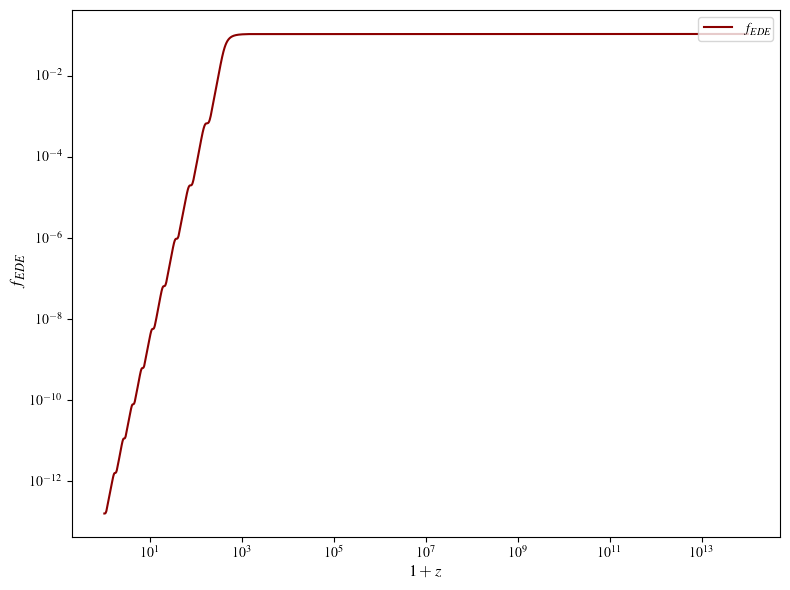

In [9]:
# Prepare the data
z = bg1['z']
z_eq = derived['z_eq']
z_rec = derived['z_rec']
#w_fld_EDE1 = bg1['(.)w_fld']
#w_fld_EDEm = bg_m['(.)w_fld']
rho_EDE1 = bg1['(.)rho_scf']
rho_tot_EDE1 = bg1['(.)rho_tot']
f_1 = rho_EDE1 / rho_tot_EDE1  # This will go on the right-hand y-axis

#rho_EDEm = bg_m['(.)rho_fld']
#rho_tot_EDEm = bg_m['(.)rho_tot']
#f_m = rho_EDEm / rho_tot_EDEm  # This will go on the right-hand y-axis
fig, ax = plt.subplots()
ax.plot(1+z, rho_EDE1, label=r'$f_{EDE}$', color='darkred')
#ax.plot(z, f_m, label=r'$f_{mEDE}$', color='darkblue')
ax.set_xlabel(r'$1+z$',fontsize='large')
ax.set_ylabel(r'$f_{EDE}$',fontsize='large')
#ax.set_ylim(0, .1)  # Set based on physical expectations
#ax.tick_params(colors='darkred')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1, 1))
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

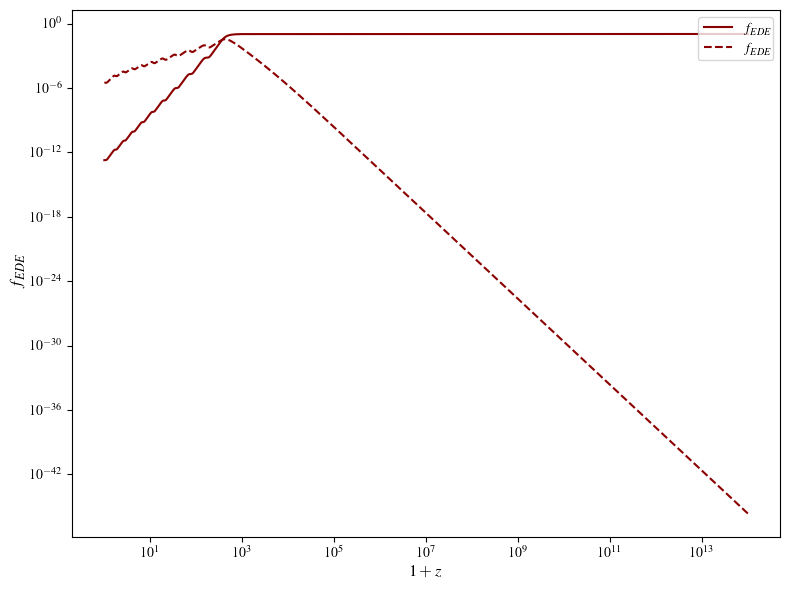

In [10]:
# Prepare the data
z = bg_m['z']
# z_eq = derived['z_eq']
# z_rec = derived['z_rec']
#w_fld_EDE1 = bg1['(.)w_fld']
#w_fld_EDEm = bg_m['(.)w_fld']
rho_EDE_m0 = bg_m['(.)rho_mscf[0]']
rho_EDE_m1 = bg_m['(.)rho_mscf[1]']
rho_tot_EDE_m = bg_m['(.)rho_tot']
f_1 = rho_EDE1 / rho_tot_EDE1  # This will go on the right-hand y-axis

#rho_EDEm = bg_m['(.)rho_fld']
#rho_tot_EDEm = bg_m['(.)rho_tot']
#f_m = rho_EDEm / rho_tot_EDEm  # This will go on the right-hand y-axis
fig, ax = plt.subplots()
ax.plot(1+z, rho_EDE_m0, label=r'$f_{EDE}$', color='darkred')
ax.plot(1+z, rho_EDE_m1, label=r'$f_{EDE}$', color='darkred', linestyle='dashed')
#ax.plot(z, f_m, label=r'$f_{mEDE}$', color='darkblue')
ax.set_xlabel(r'$1+z$',fontsize='large')
ax.set_ylabel(r'$f_{EDE}$',fontsize='large')
#ax.set_ylim(0, .1)  # Set based on physical expectations
#ax.tick_params(colors='darkred')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper right', bbox_to_anchor=(1, 1))
ax.set_xscale('log')
ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [60]:
EDE1.empty()
#EDEm.empty()